In [ ]:
import numpy as np
import pandas as pd


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving diabetes 2.csv to diabetes 2.csv


In [ ]:
df = pd.read_csv('diabetes 2.csv')

In [ ]:
print("=" * 60)                        # prints a separator line for readability
print("1.1 BASIC SHAPE & STRUCTURE")
print("=" * 60)
print(f"Rows: {df.shape[0]}")          # df.shape[0] = number of rows (768)
print(f"Columns: {df.shape[1]}")       # df.shape[1] = number of columns (9)
print(f"\nColumn Names:\n{list(df.columns)}")   # lists all column names
print(f"\nData Types:\n{df.dtypes}")

1.1 BASIC SHAPE & STRUCTURE
Rows: 768
Columns: 9

Column Names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [ ]:
# ── 1.2 First & last few rows ──
print("\n" + "=" * 60)
print("1.2 FIRST 5 ROWS")
print("=" * 60)
print(df.head())        # shows first 5 rows — checks if data loaded correctly

print("\n" + "=" * 60)
print("LAST 5 ROWS")
print("=" * 60)
print(df.tail())        # shows last 5 rows — checks for junk/footer rows at the end



1.2 FIRST 5 ROWS
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

LAST 5 ROWS
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72          

In [ ]:
# ── 1.3 Summary Statistics ──
print("\n" + "=" * 60)
print("1.3 DESCRIPTIVE STATISTICS")
print("=" * 60)
print(df.describe().round(2))


1.3 DESCRIPTIVE STATISTICS
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean          3.85   120.89          69.11          20.54    79.80   31.99   
std           3.37    31.97          19.36          15.95   115.24    7.88   
min           0.00     0.00           0.00           0.00     0.00    0.00   
25%           1.00    99.00          62.00           0.00     0.00   27.30   
50%           3.00   117.00          72.00          23.00    30.50   32.00   
75%           6.00   140.25          80.00          32.00   127.25   36.60   
max          17.00   199.00         122.00          99.00   846.00   67.10   

       DiabetesPedigreeFunction     Age  Outcome  
count                    768.00  768.00   768.00  
mean                       0.47   33.24     0.35  
std                        0.33   11.76     0.48  
min                        0.08   21.00     0.00  
25%           

In [ ]:
# ── 1.4 Missing Values Check ──
print("\n" + "=" * 60)
print("1.4 MISSING VALUES (NaN)")
print("=" * 60)
print(df.isnull().sum())   # counts NaN values in each column
print(f"\nTotal NaN in dataset: {df.isnull().sum().sum()}")
# total NaN across entire dataset



1.4 MISSING VALUES (NaN)
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Total NaN in dataset: 0


In [ ]:
# ── 1.5 Zero-Value Analysis (biologically implausible) ──
# A person can't have 0 blood pressure or 0 BMI — these zeros are actually missing data
print("\n" + "=" * 60)
print("1.5 ZERO-VALUE ANALYSIS (Potential Missing Data)")
print("=" * 60)
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']   # columns where 0 is impossible
for col in zero_cols:                          # loop through each column
    count = (df[col] == 0).sum()               # count how many zeros
    pct = (count / len(df)) * 100              # calculate percentage
    print(f"  {col:30s}: {count:4d} zeros  ({pct:.1f}%)")   # formatted output



1.5 ZERO-VALUE ANALYSIS (Potential Missing Data)
  Glucose                       :    5 zeros  (0.7%)
  BloodPressure                 :   35 zeros  (4.6%)
  SkinThickness                 :  227 zeros  (29.6%)
  Insulin                       :  374 zeros  (48.7%)
  BMI                           :   11 zeros  (1.4%)


In [ ]:
# ── 1.7 Duplicates Check ──
print("\n" + "=" * 60)
print("1.7 DUPLICATE ROWS")
print("=" * 60)
dup_count = df.duplicated().sum()       # checks if any rows are exact copies of another row
print(f"  Duplicate rows found: {dup_count}")


1.7 DUPLICATE ROWS
  Duplicate rows found: 0


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# statsmodels — for Logistic Regression with p-values, odds ratios, CIs
import statsmodels.api as sm

# scikit-learn — for model building and evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)
from sklearn.impute import SimpleImputer

In [13]:
# for multicollinearity check
from statsmodels.stats.outliers_influence import variance_inflation_factor

# set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [14]:
# ══════════════════════════════════════════════════════════════
# PHASE 2: DATA CLEANING & PREPROCESSING
# ══════════════════════════════════════════════════════════════
print("=" * 60)
print("PHASE 2: DATA CLEANING & PREPROCESSING")
print("=" * 60)

# ── 2.1 Replace biologically implausible zeros with NaN ──
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df_clean = df.copy()    # work on a copy so original stays untouched

for col in zero_cols:
    df_clean[col] = df_clean[col].replace(0, np.nan)

print("\n2.1 After replacing zeros with NaN:")
print(df_clean.isnull().sum())
print(f"\nTotal missing values now: {df_clean.isnull().sum().sum()}")

# ── 2.2 Median Imputation ──
for col in zero_cols:
    median_val = df_clean[col].median()
    df_clean[col].fillna(median_val, inplace=True)
    print(f"  {col} → filled with median: {median_val}")

print("\nAfter imputation — missing values:")
print(df_clean.isnull().sum())

# ── 2.3 Verify the fix ──
print("\n2.3 Descriptive stats AFTER cleaning:")
print(df_clean.describe().round(2))

# ── 2.4 Outlier Detection using IQR ──
print("\n" + "=" * 60)
print("2.4 OUTLIER DETECTION (IQR Method)")
print("=" * 60)

for col in df_clean.columns[:-1]:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    print(f"  {col:30s}: {outliers:4d} outliers")

print("\n  → Outliers detected but NOT removed (may be clinically meaningful)")


PHASE 2: DATA CLEANING & PREPROCESSING

2.1 After replacing zeros with NaN:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Total missing values now: 652
  Glucose → filled with median: 117.0
  BloodPressure → filled with median: 72.0
  SkinThickness → filled with median: 29.0
  Insulin → filled with median: 125.0
  BMI → filled with median: 32.3

After imputation — missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

2.3 Descriptive stats AFTER cleaning:
       Pregnancies  Glucose  BloodPress


PHASE 3: EXPLORATORY DATA ANALYSIS (EDA)


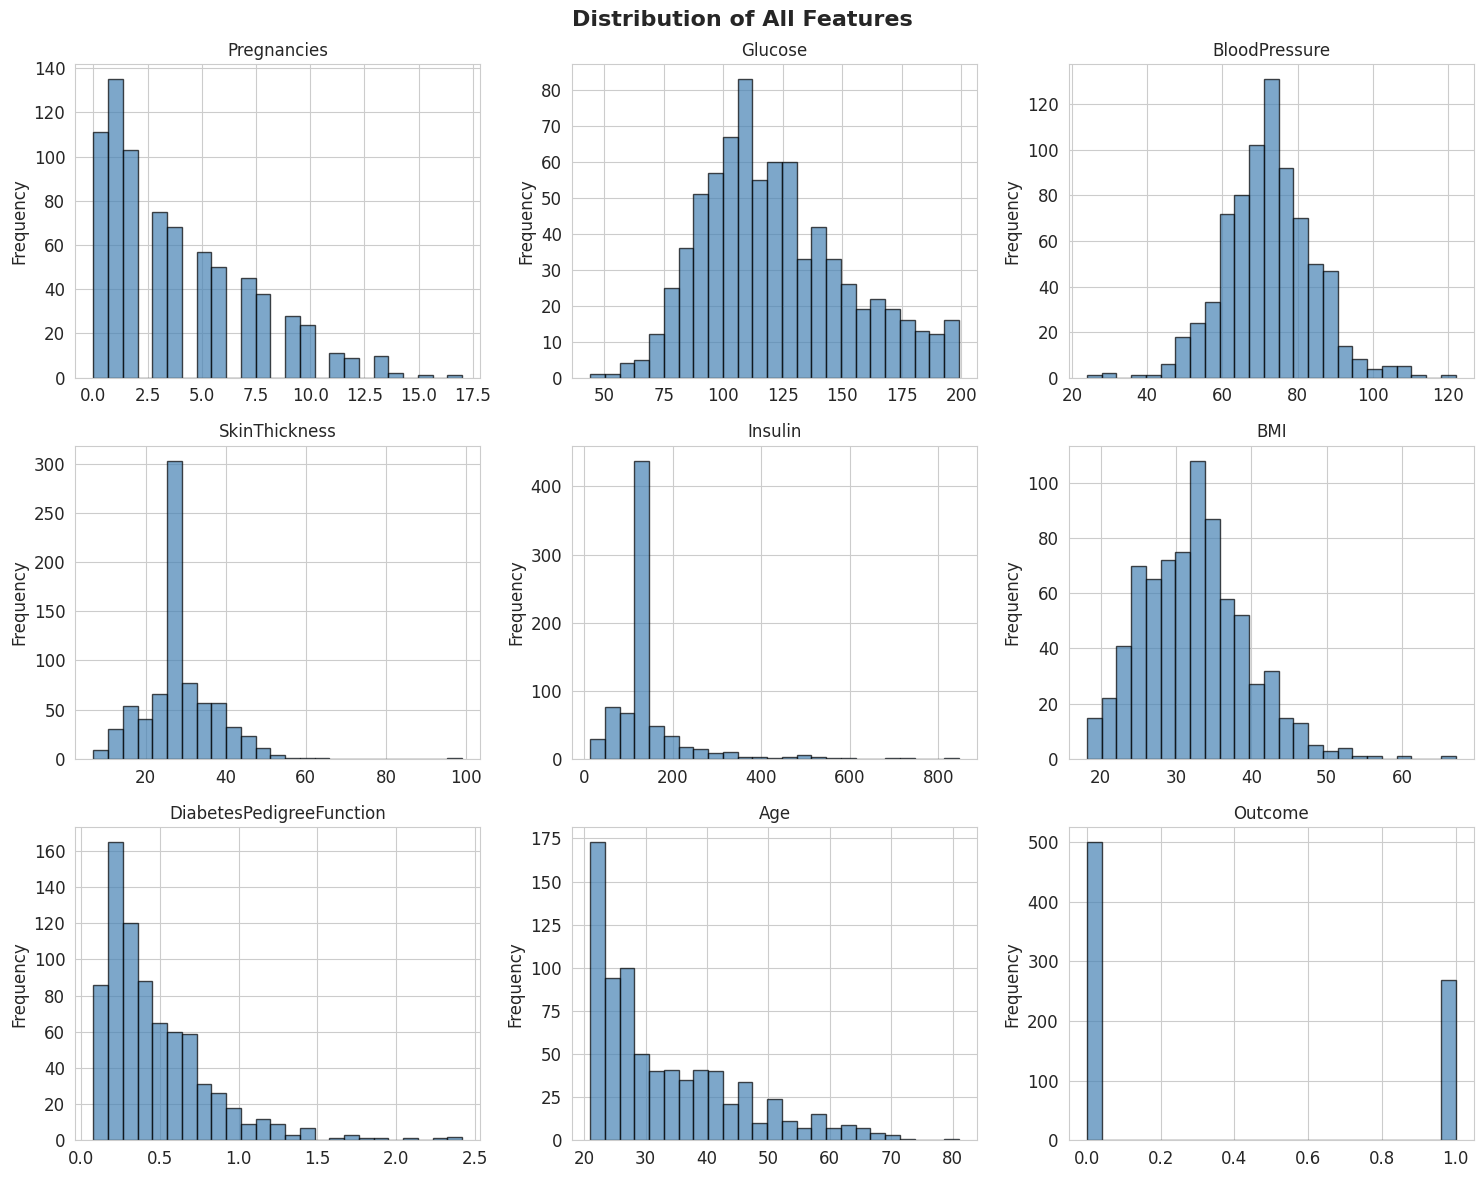

  ✓ Plot 1: Histograms


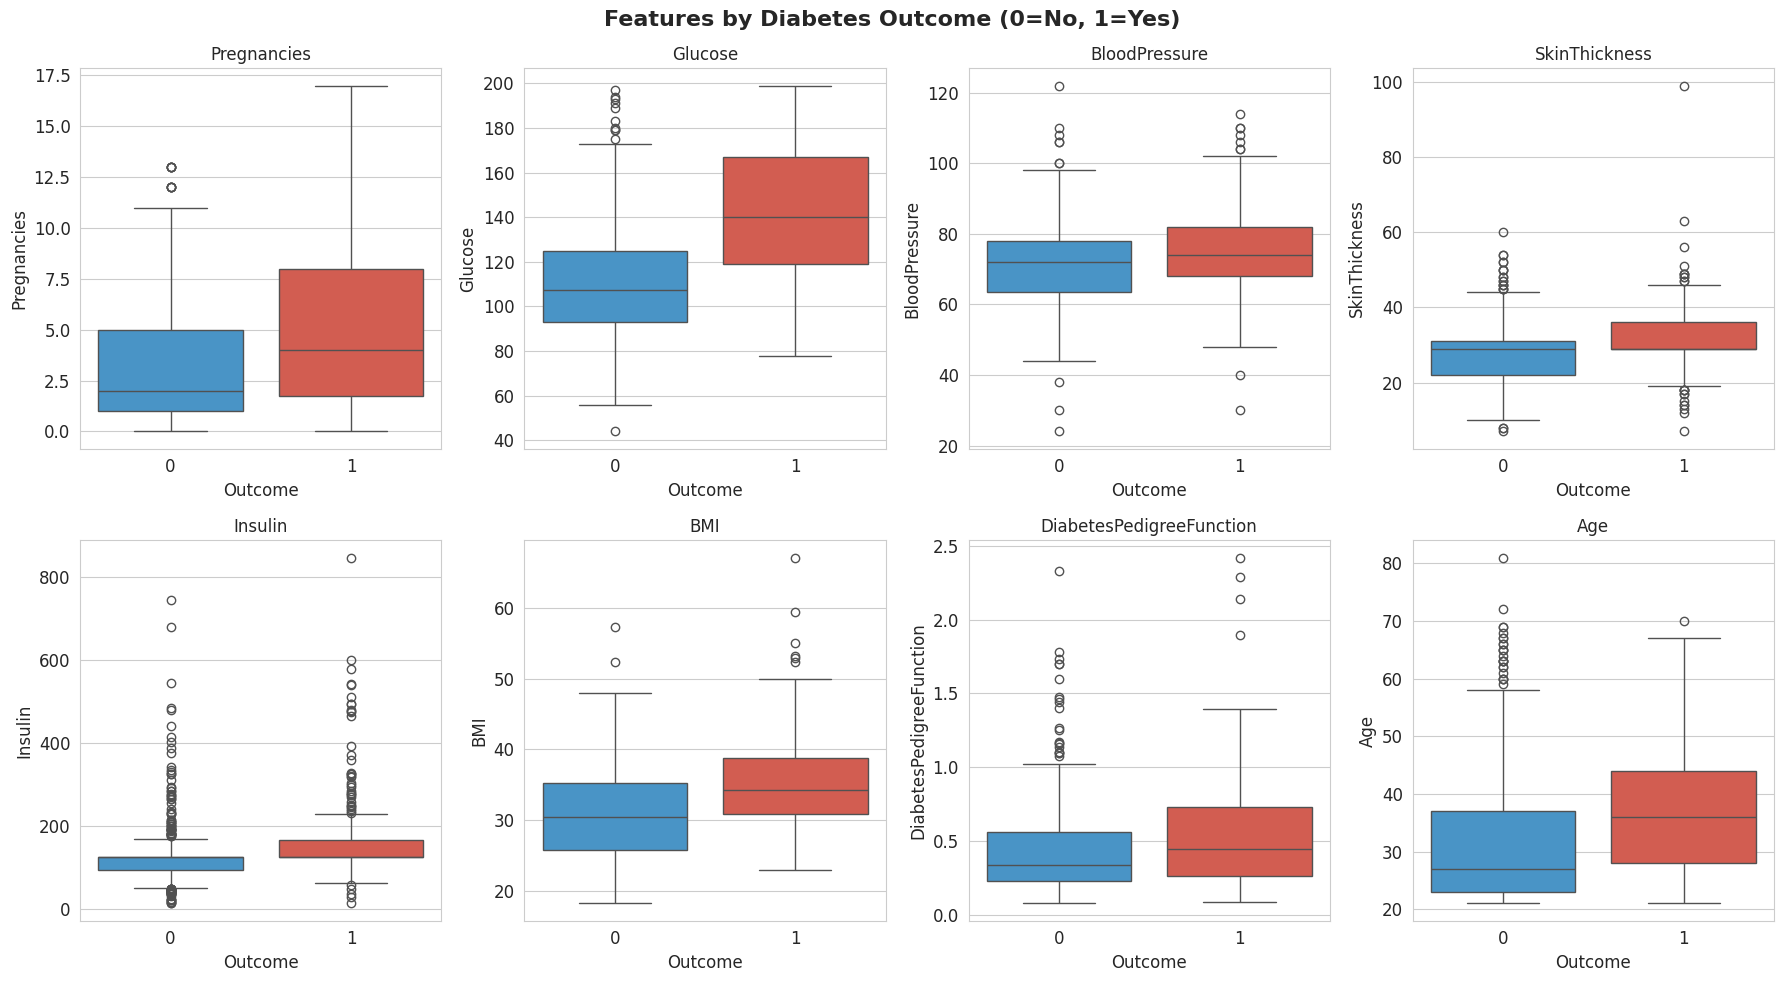

  ✓ Plot 2: Boxplots by Outcome


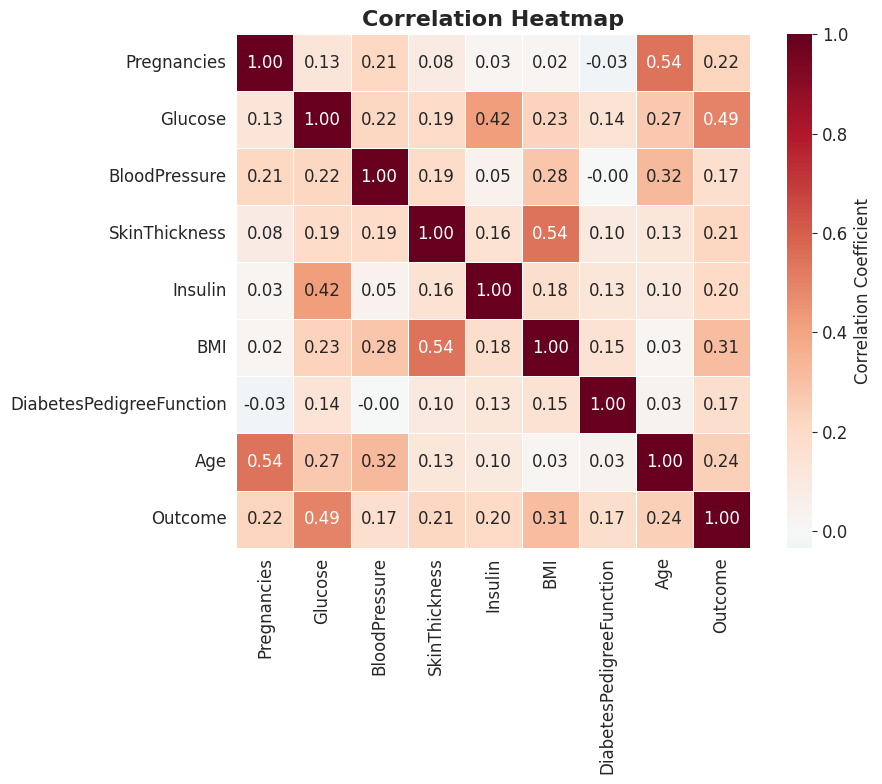

  ✓ Plot 3: Correlation Heatmap


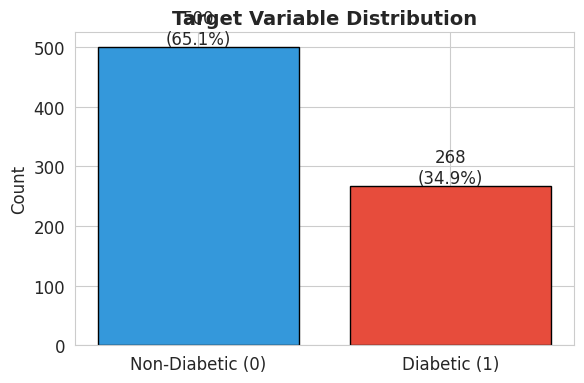

  ✓ Plot 4: Target Distribution


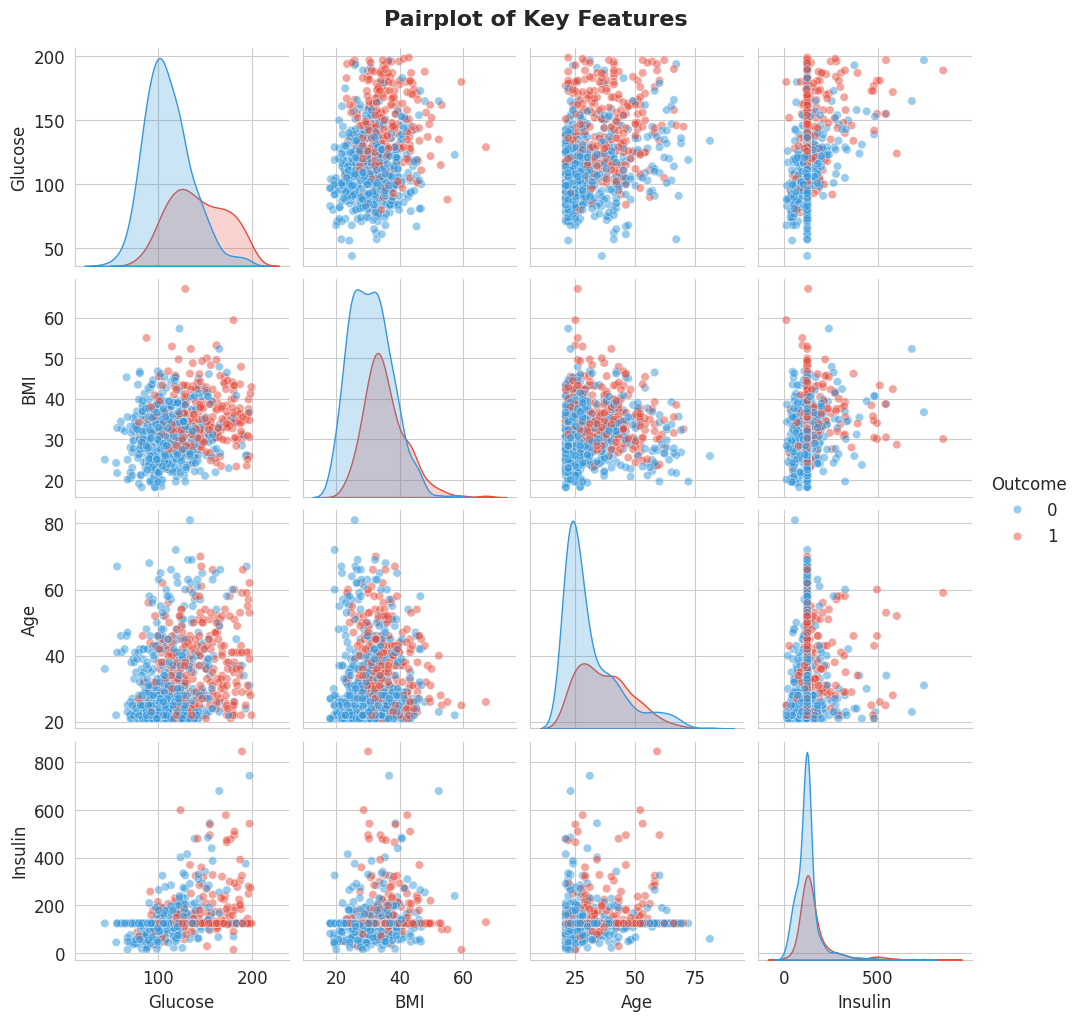

  ✓ Plot 5: Pairplot


In [15]:
# ══════════════════════════════════════════════════════════════
# PHASE 3: EXPLORATORY DATA ANALYSIS (EDA)
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("PHASE 3: EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 60)

# ── 3.1 Distribution of each feature (Histograms) ──
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Distribution of All Features', fontsize=16, fontweight='bold')

for i, col in enumerate(df_clean.columns):
    row = i // 3
    col_idx = i % 3
    axes[row, col_idx].hist(df_clean[col], bins=25, color='steelblue', edgecolor='black', alpha=0.7)
    axes[row, col_idx].set_title(col, fontsize=12)
    axes[row, col_idx].set_xlabel('')
    axes[row, col_idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()
print("  ✓ Plot 1: Histograms")

# ── 3.2 Boxplots grouped by Outcome ──
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Features by Diabetes Outcome (0=No, 1=Yes)', fontsize=16, fontweight='bold')

features = df_clean.columns[:-1]
for i, col in enumerate(features):
    row = i // 4
    col_idx = i % 4
    sns.boxplot(x='Outcome', y=col, data=df_clean, ax=axes[row, col_idx],
                palette=['#3498db', '#e74c3c'])
    axes[row, col_idx].set_title(col, fontsize=12)

plt.tight_layout()
plt.show()
print("  ✓ Plot 2: Boxplots by Outcome")

# ── 3.3 Correlation Heatmap ──
plt.figure(figsize=(10, 8))
corr_matrix = df_clean.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print("  ✓ Plot 3: Correlation Heatmap")

# ── 3.4 Target Variable Distribution ──
plt.figure(figsize=(6, 4))
colors = ['#3498db', '#e74c3c']
outcome_counts = df_clean['Outcome'].value_counts()
bars = plt.bar(['Non-Diabetic (0)', 'Diabetic (1)'], outcome_counts.values, color=colors, edgecolor='black')
for bar, count in zip(bars, outcome_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count}\n({count/len(df_clean)*100:.1f}%)', ha='center', fontsize=12)
plt.title('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print("  ✓ Plot 4: Target Distribution")

# ── 3.5 Pairwise relationships for key features ──
key_features = ['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome']
sns.pairplot(df_clean[key_features], hue='Outcome', palette=['#3498db', '#e74c3c'],
             diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot of Key Features', y=1.02, fontsize=16, fontweight='bold')
plt.show()
print("  ✓ Plot 5: Pairplot")



In [16]:
# ══════════════════════════════════════════════════════════════
# PHASE 4: FEATURE ENGINEERING & PREPARATION
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("PHASE 4: FEATURE ENGINEERING & PREPARATION")
print("=" * 60)

# ── 4.1 Separate features (X) and target (y) ──
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

print(f"\n4.1 Features shape: {X.shape}")
print(f"    Target shape:   {y.shape}")

# ── 4.2 Multicollinearity Check (VIF) ──
print("\n4.2 Variance Inflation Factor (VIF):")
X_with_const = sm.add_constant(X)
vif_data = pd.DataFrame({
    'Feature': X.columns,
    'VIF': [variance_inflation_factor(X_with_const.values, i+1) for i in range(X.shape[1])]
})
print(vif_data.to_string(index=False))

# ── 4.3 Train/Test Split ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n4.3 Train/Test Split:")
print(f"    Training set: {X_train.shape[0]} samples")
print(f"    Testing set:  {X_test.shape[0]} samples")
print(f"    Train class distribution:\n{y_train.value_counts()}")

# ── 4.4 Feature Scaling (for Logistic Regression only) ──
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("\n4.4 Feature Scaling applied (StandardScaler)")
print("    Scaled training data sample:")
print(X_train_scaled.head(3).round(2))



PHASE 4: FEATURE ENGINEERING & PREPARATION

4.1 Features shape: (768, 8)
    Target shape:   (768,)

4.2 Variance Inflation Factor (VIF):
                 Feature      VIF
             Pregnancies 1.430466
                 Glucose 1.361314
           BloodPressure 1.242670
           SkinThickness 1.451029
                 Insulin 1.239392
                     BMI 1.572588
DiabetesPedigreeFunction 1.048391
                     Age 1.616142

4.3 Train/Test Split:
    Training set: 614 samples
    Testing set:  154 samples
    Train class distribution:
Outcome
0    400
1    214
Name: count, dtype: int64

4.4 Feature Scaling applied (StandardScaler)
    Scaled training data sample:
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
353        -0.85    -1.06          -0.83          -1.92    -1.20 -0.77   
711         0.36     0.14           0.48          -0.23    -1.47 -0.42   
373        -0.55    -0.56          -1.15           1.23    -0.56  0.36   

     DiabetesP

In [17]:
# ══════════════════════════════════════════════════════════════
# PHASE 5: MODEL BUILDING
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("PHASE 5: MODEL BUILDING")
print("=" * 60)

# ── 5.1 Logistic Regression (statsmodels — for statistical output) ──
print("\n5.1 LOGISTIC REGRESSION (statsmodels)")
print("-" * 40)

X_train_sm = sm.add_constant(X_train_scaled)
X_test_sm = sm.add_constant(X_test_scaled)

logit_model = sm.Logit(y_train, X_train_sm)
logit_result = logit_model.fit()
print(logit_result.summary())

# ── 5.2 Logistic Regression (scikit-learn — for predictions) ──
print("\n5.2 LOGISTIC REGRESSION (scikit-learn)")
print("-" * 40)

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_predictions = lr_model.predict(X_test_scaled)
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print("  Logistic Regression trained successfully.")


PHASE 5: MODEL BUILDING

5.1 LOGISTIC REGRESSION (statsmodels)
----------------------------------------
Optimization terminated successfully.
         Current function value: 0.453071
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                  614
Model:                          Logit   Df Residuals:                      605
Method:                           MLE   Df Model:                            8
Date:                Tue, 07 Apr 2026   Pseudo R-squ.:                  0.2992
Time:                        06:52:03   Log-Likelihood:                -278.19
converged:                       True   LL-Null:                       -396.97
Covariance Type:            nonrobust   LLR p-value:                 7.392e-47
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

In [18]:
# ── 5.3 Decision Tree ──
print("\n5.3 DECISION TREE CLASSIFIER")
print("-" * 40)

dt_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)
dt_proba = dt_model.predict_proba(X_test)[:, 1]

print("  Decision Tree trained successfully.")


5.3 DECISION TREE CLASSIFIER
----------------------------------------
  Decision Tree trained successfully.


In [19]:
# ── 5.4 Cross-Validation (5-Fold) ──
print("\n5.4 CROSS-VALIDATION (5-Fold)")
print("-" * 40)

lr_cv = cross_val_score(LogisticRegression(random_state=42, max_iter=1000),
                        X_train_scaled, y_train, cv=5, scoring='accuracy')
dt_cv = cross_val_score(DecisionTreeClassifier(max_depth=4, min_samples_split=10,
                        min_samples_leaf=5, random_state=42),
                        X_train, y_train, cv=5, scoring='accuracy')

print(f"  Logistic Regression CV Accuracy: {lr_cv.mean():.4f} ± {lr_cv.std():.4f}")
print(f"  Decision Tree CV Accuracy:       {dt_cv.mean():.4f} ± {dt_cv.std():.4f}")




5.4 CROSS-VALIDATION (5-Fold)
----------------------------------------
  Logistic Regression CV Accuracy: 0.7818 ± 0.0125
  Decision Tree CV Accuracy:       0.7133 ± 0.0126



PHASE 6: MODEL EVALUATION


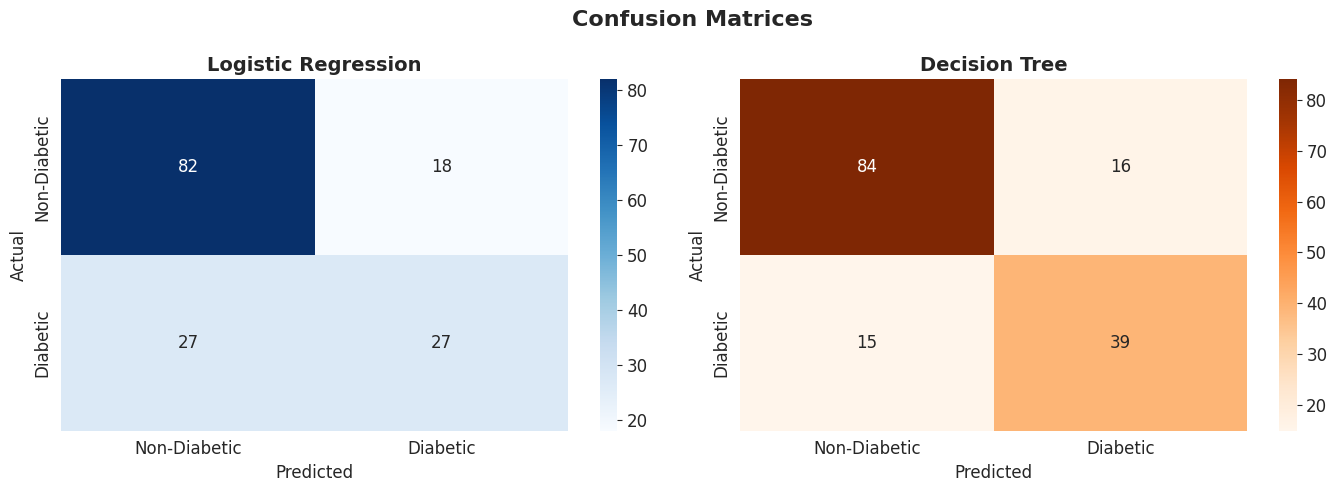

  ✓ Plot 6: Confusion Matrices

6.2 CLASSIFICATION REPORTS

Logistic Regression:
              precision    recall  f1-score   support

Non-Diabetic       0.75      0.82      0.78       100
    Diabetic       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154

Decision Tree:
              precision    recall  f1-score   support

Non-Diabetic       0.85      0.84      0.84       100
    Diabetic       0.71      0.72      0.72        54

    accuracy                           0.80       154
   macro avg       0.78      0.78      0.78       154
weighted avg       0.80      0.80      0.80       154



In [20]:
# ══════════════════════════════════════════════════════════════
# PHASE 6: MODEL EVALUATION
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("PHASE 6: MODEL EVALUATION")
print("=" * 60)

# ── 6.1 Confusion Matrices ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_lr = confusion_matrix(y_test, lr_predictions)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
axes[0].set_title('Logistic Regression', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

cm_dt = confusion_matrix(y_test, dt_predictions)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
axes[1].set_title('Decision Tree', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print("  ✓ Plot 6: Confusion Matrices")

# ── 6.2 Classification Reports ──
print("\n6.2 CLASSIFICATION REPORTS")
print("\nLogistic Regression:")
print(classification_report(y_test, lr_predictions, target_names=['Non-Diabetic', 'Diabetic']))

print("Decision Tree:")
print(classification_report(y_test, dt_predictions, target_names=['Non-Diabetic', 'Diabetic']))



6.3 MODEL COMPARISON TABLE
--------------------------------------------------
   Metric  Logistic Regression  Decision Tree
 Accuracy               0.7078         0.7987
Precision               0.6000         0.7091
   Recall               0.5000         0.7222
 F1-Score               0.5455         0.7156
  ROC-AUC               0.8130         0.8248


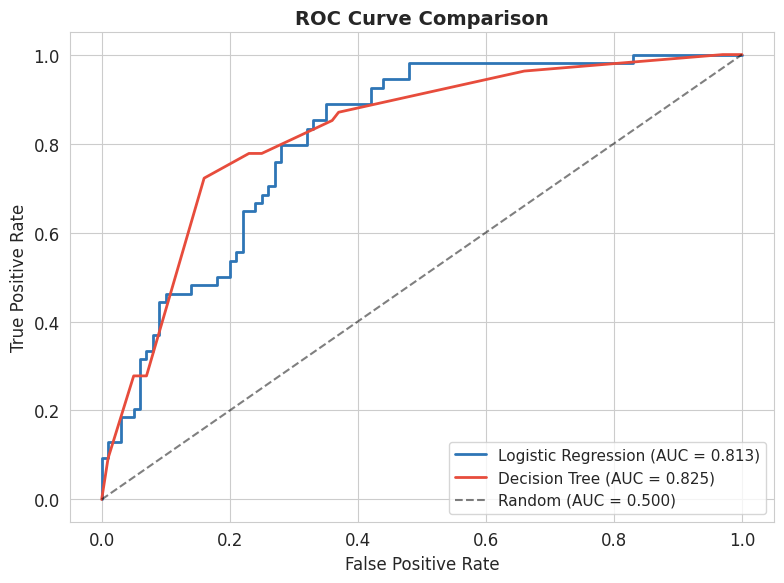

  ✓ Plot 7: ROC Curves


In [21]:
# ── 6.3 Model Comparison Table ──
print("\n6.3 MODEL COMPARISON TABLE")
print("-" * 50)

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Logistic Regression': [
        accuracy_score(y_test, lr_predictions),
        precision_score(y_test, lr_predictions),
        recall_score(y_test, lr_predictions),
        f1_score(y_test, lr_predictions),
        roc_auc_score(y_test, lr_proba)
    ],
    'Decision Tree': [
        accuracy_score(y_test, dt_predictions),
        precision_score(y_test, dt_predictions),
        recall_score(y_test, dt_predictions),
        f1_score(y_test, dt_predictions),
        roc_auc_score(y_test, dt_proba)
    ]
})
comparison[['Logistic Regression', 'Decision Tree']] = comparison[['Logistic Regression', 'Decision Tree']].round(4)
print(comparison.to_string(index=False))

# ── 6.4 ROC Curves ──
plt.figure(figsize=(8, 6))

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
plt.plot(fpr_lr, tpr_lr, color='#2E75B6', linewidth=2,
         label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_proba):.3f})')

fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_proba)
plt.plot(fpr_dt, tpr_dt, color='#E74C3C', linewidth=2,
         label=f'Decision Tree (AUC = {roc_auc_score(y_test, dt_proba):.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC = 0.500)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()
print("  ✓ Plot 7: ROC Curves")


PHASE 7: STATISTICAL INTERPRETATION

7.1 ODDS RATIOS & 95% CONFIDENCE INTERVALS
--------------------------------------------------
                 Feature  Coefficient  Odds Ratio  CI Lower (95%)  CI Upper (95%)  P-value Significant
             Pregnancies       0.3858      1.4707          1.1538          1.8747   0.0018       Yes ✓
                 Glucose       1.2069      3.3432          2.5566          4.3717   0.0000       Yes ✓
           BloodPressure      -0.0507      0.9506          0.7543          1.1978   0.6674          No
           SkinThickness       0.0213      1.0216          0.7883          1.3238   0.8718          No
                 Insulin      -0.0762      0.9267          0.7362          1.1663   0.5163          No
                     BMI       0.7060      2.0260          1.5384          2.6681   0.0000       Yes ✓
DiabetesPedigreeFunction       0.2366      1.2669          1.0191          1.5751   0.0332       Yes ✓
                     Age       0.1466      1

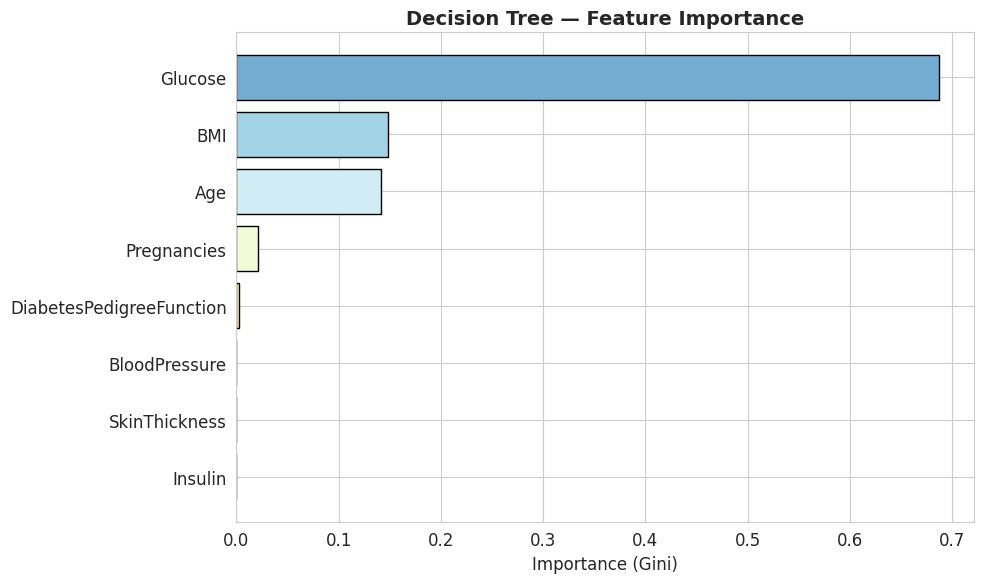

  ✓ Plot 8: Feature Importance


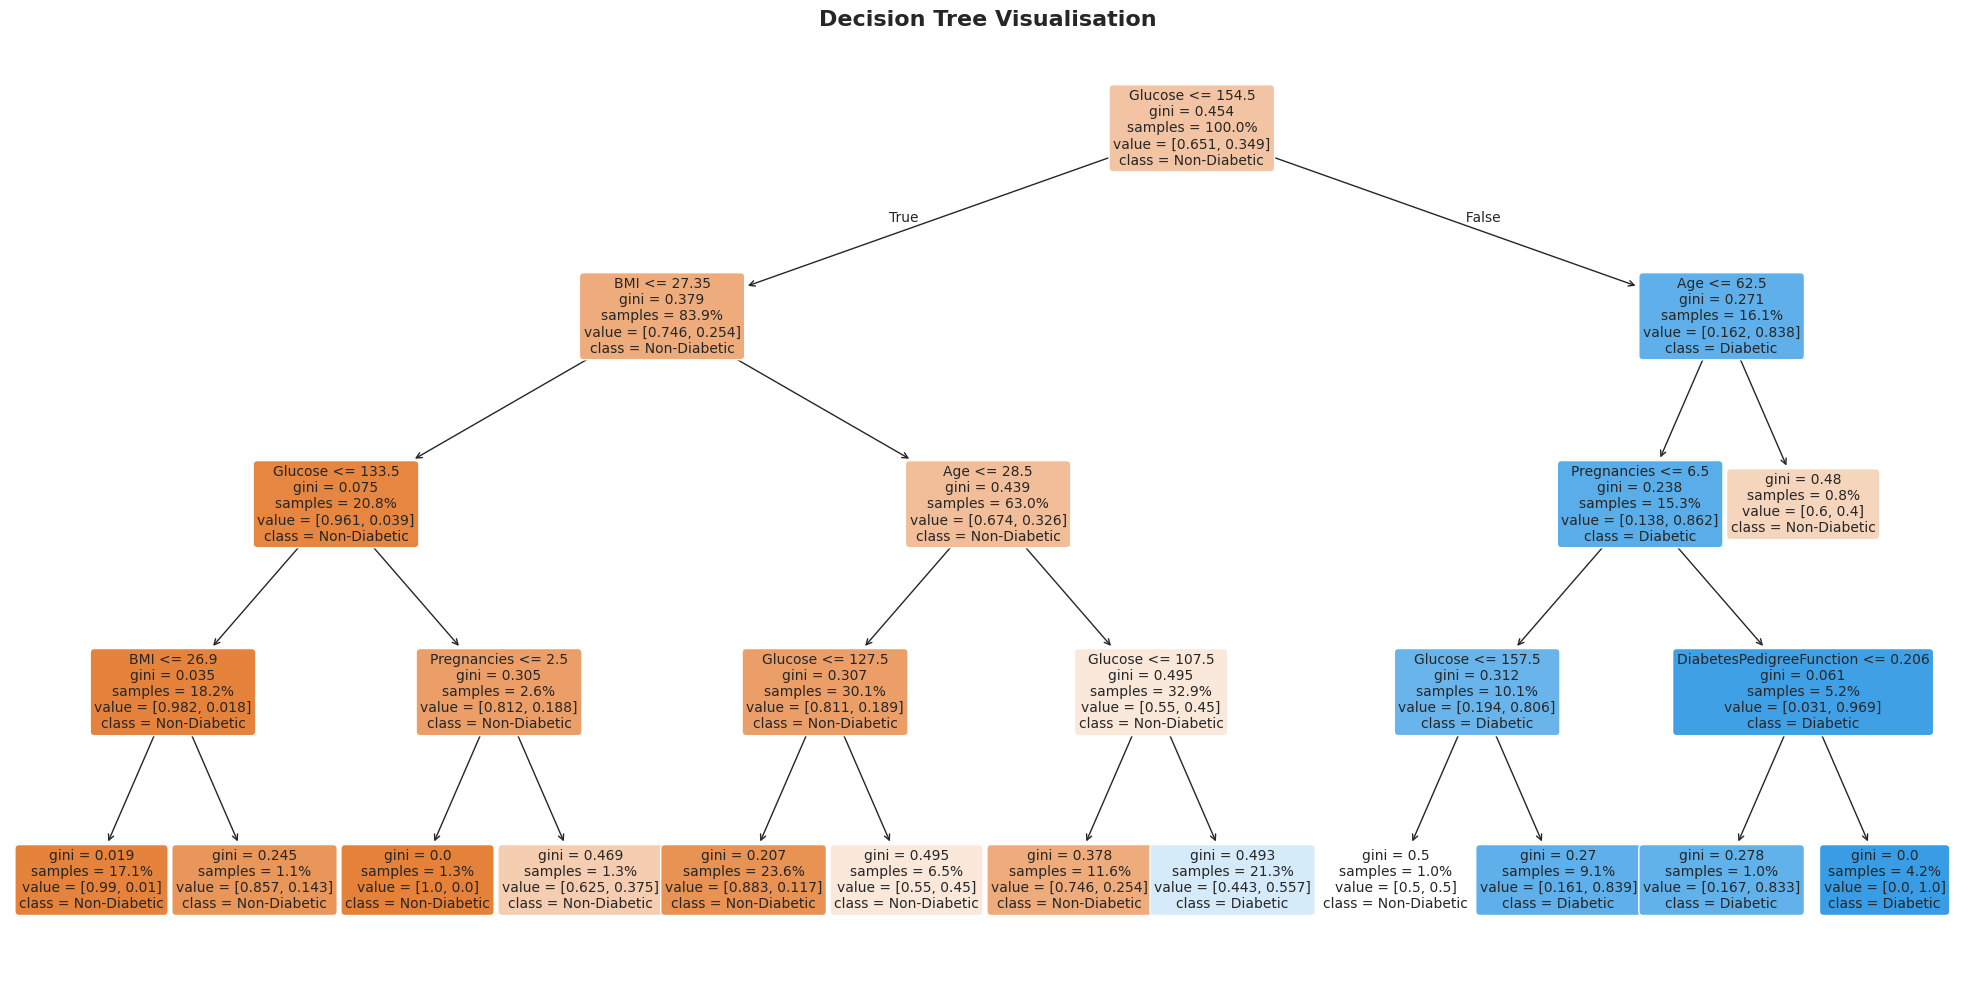

  ✓ Plot 9: Decision Tree

PHASE 8: FINAL SUMMARY & CONCLUSIONS

DATASET:
  - Pima Indians Diabetes Dataset: 768 records, 8 features
  - Target: Outcome (0 = Non-Diabetic, 1 = Diabetic)
  - Class Balance: 500 non-diabetic (65.1%) vs 268 diabetic (34.9%)

DATA CLEANING:
  - Replaced biologically implausible zeros with NaN in 5 columns
  - Applied median imputation to fill missing values
  - Outliers detected but retained (clinically valid)

MODEL PERFORMANCE:
  Logistic Regression:
    - Accuracy:  0.7078
    - ROC-AUC:   0.8130
    - F1-Score:  0.5455

  Decision Tree:
    - Accuracy:  0.7987
    - ROC-AUC:   0.8248
    - F1-Score:  0.7156

KEY FINDINGS:
  - Significant predictors identified via Logistic Regression (p < 0.05):
      • Pregnancies (OR = 1.471, p = 0.0018)
      • Glucose (OR = 3.343, p = 0.0000)
      • BMI (OR = 2.026, p = 0.0000)
      • DiabetesPedigreeFunction (OR = 1.267, p = 0.0332)

  - Decision Tree confirms top predictors via Gini importance
  - Both models sho

In [23]:
# ══════════════════════════════════════════════════════════════
# PHASE 7: STATISTICAL INTERPRETATION
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("PHASE 7: STATISTICAL INTERPRETATION")
print("=" * 60)

# ── 7.1 Odds Ratios and Confidence Intervals ──
print("\n7.1 ODDS RATIOS & 95% CONFIDENCE INTERVALS")
print("-" * 50)

params = logit_result.params[1:]
conf = logit_result.conf_int().iloc[1:]
pvalues = logit_result.pvalues[1:]

odds_ratio_table = pd.DataFrame({
    'Feature': params.index,
    'Coefficient': params.values.round(4),
    'Odds Ratio': np.exp(params.values).round(4),
    'CI Lower (95%)': np.exp(conf[0].values).round(4),
    'CI Upper (95%)': np.exp(conf[1].values).round(4),
    'P-value': pvalues.values.round(4),
    'Significant': ['Yes ✓' if p < 0.05 else 'No' for p in pvalues.values]
})

print(odds_ratio_table.to_string(index=False))

# ── 7.2 Interpret significant predictors ──
print("\n7.2 INTERPRETATION OF SIGNIFICANT PREDICTORS")
print("-" * 50)
sig_features = odds_ratio_table[odds_ratio_table['P-value'] < 0.05]

for _, row in sig_features.iterrows():
    or_val = row['Odds Ratio']
    direction = "increases" if or_val > 1 else "decreases"
    pct_change = abs(or_val - 1) * 100
    print(f"\n  {row['Feature']}:")
    print(f"    Odds Ratio = {or_val:.4f} (p = {row['P-value']:.4f})")
    print(f"    → A 1-SD increase in {row['Feature']} {direction} the odds of diabetes by {pct_change:.1f}%")

# ── 7.3 Decision Tree Feature Importance ──
print("\n\n7.3 DECISION TREE — FEATURE IMPORTANCE")
print("-" * 50)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance.to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, len(importance)))
bars = plt.barh(importance['Feature'], importance['Importance'], color=colors, edgecolor='black')
plt.xlabel('Importance (Gini)', fontsize=12)
plt.title('Decision Tree — Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print("  ✓ Plot 8: Feature Importance")

# ── 7.4 Visualise the Decision Tree ──
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=list(X.columns),
          class_names=['Non-Diabetic', 'Diabetic'],
          filled=True, rounded=True, fontsize=10,
          proportion=True)
plt.title('Decision Tree Visualisation', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print("  ✓ Plot 9: Decision Tree")


# ══════════════════════════════════════════════════════════════
# PHASE 8: FINAL SUMMARY & CONCLUSIONS
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("PHASE 8: FINAL SUMMARY & CONCLUSIONS")
print("=" * 60)

print(f"""
DATASET:
  - Pima Indians Diabetes Dataset: {len(df_clean)} records, {X.shape[1]} features
  - Target: Outcome (0 = Non-Diabetic, 1 = Diabetic)
  - Class Balance: {(y==0).sum()} non-diabetic ({(y==0).sum()/len(y)*100:.1f}%) vs {(y==1).sum()} diabetic ({(y==1).sum()/len(y)*100:.1f}%)

DATA CLEANING:
  - Replaced biologically implausible zeros with NaN in 5 columns
  - Applied median imputation to fill missing values
  - Outliers detected but retained (clinically valid)

MODEL PERFORMANCE:
  Logistic Regression:
    - Accuracy:  {accuracy_score(y_test, lr_predictions):.4f}
    - ROC-AUC:   {roc_auc_score(y_test, lr_proba):.4f}
    - F1-Score:  {f1_score(y_test, lr_predictions):.4f}

  Decision Tree:
    - Accuracy:  {accuracy_score(y_test, dt_predictions):.4f}
    - ROC-AUC:   {roc_auc_score(y_test, dt_proba):.4f}
    - F1-Score:  {f1_score(y_test, dt_predictions):.4f}

KEY FINDINGS:
  - Significant predictors identified via Logistic Regression (p < 0.05):""")

for _, row in sig_features.iterrows():
    print(f"      • {row['Feature']} (OR = {row['Odds Ratio']:.3f}, p = {row['P-value']:.4f})")

print(f"""
  - Decision Tree confirms top predictors via Gini importance
  - Both models show Glucose as the strongest predictor of diabetes

CONCLUSION:
  Logistic Regression provides a statistically interpretable model for
  identifying key risk factors for diabetes. The Decision Tree offers
  a complementary non-parametric perspective. Together, they provide
  robust evidence for which clinical factors matter most.
""")

print("=" * 60)
print("PROJECT COMPLETE — All 8 Phases Finished")
print("=" * 60)